In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
!free -h

              total        used        free      shared  buff/cache   available
Mem:          251Gi        12Gi       112Gi       138Mi       126Gi       237Gi
Swap:         124Gi       146Mi       124Gi


In [3]:
ratings = pd.read_csv(
	"../ml1m/ratings.dat",
	sep="::",
	names=["user_id", "movie_id", "rating", "timestamp"],
	encoding="latin-1",
	engine="python"
)

movies = pd.read_csv(
	"../ml1m/movies.dat",
	sep="::",
	names=["movie_id", "title", "genres"],
	encoding="latin-1",   # ← this is the key fix
	engine="python"
)
users = pd.read_csv(
	"../ml1m/users.dat",
	sep="::",
	names=["user_id", "gender", "age","occupation","zip_code"],
	encoding="latin-1",   # ← this is the key fix
	engine="python"
)

In [4]:
movies.head(),ratings.head(),users.head()

(   movie_id                               title                        genres
 0         1                    Toy Story (1995)   Animation|Children's|Comedy
 1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
 2         3             Grumpier Old Men (1995)                Comedy|Romance
 3         4            Waiting to Exhale (1995)                  Comedy|Drama
 4         5  Father of the Bride Part II (1995)                        Comedy,
    user_id  movie_id  rating  timestamp
 0        1      1193       5  978300760
 1        1       661       3  978302109
 2        1       914       3  978301968
 3        1      3408       4  978300275
 4        1      2355       5  978824291,
    user_id gender  age  occupation zip_code
 0        1      F    1          10    48067
 1        2      M   56          16    70072
 2        3      M   25          15    55117
 3        4      M   45           7    02460
 4        5      M   25          20    55455)

In [5]:
len(movies),len(ratings),len(users),len(users)*len(movies)

(3883, 1000209, 6040, 23453320)

In [6]:
ratings=ratings.sort_values(by='timestamp')
ratings.head(),len(ratings)

(         user_id  movie_id  rating  timestamp
 1000138     6040       858       4  956703932
 999873      6040       593       5  956703954
 1000153     6040      2384       4  956703954
 1000007     6040      1961       4  956703977
 1000192     6040      2019       5  956703977,
 1000209)

In [7]:
def temporal_sort(ratings):
	ratings=ratings.sort_values(by="timestamp")
	return ratings

In [8]:
def sort(df,col_list):
    df=df.sort_values(by=col_list)
    return df
sort(ratings,["user_id","timestamp"])

,user_id,movie_id,rating,timestamp
31,1,3186,4,978300019
37,1,1022,5,978300055
27,1,1721,4,978300055
22,1,1270,5,978300055
24,1,2340,3,978300103
...,...,...,...,...
1000019,6040,2917,4,997454429
1000172,6040,1784,3,997454464
999988,6040,1921,4,997454464
1000167,6040,161,3,997454486


In [9]:
def train_val_test_split(data,split_distribution=[0.7,0.15,0.15]):
	n=len(data)
	train_percentage,val_percentage,test_percentage=split_distribution[0],split_distribution[1],split_distribution[2]
	train_split_idx,val_split_idx=int(train_percentage*n),int((train_percentage+val_percentage)*n)
	x_train,x_val,x_test=data[:train_split_idx],data[train_split_idx:val_split_idx],data[val_split_idx:]
	return x_train,x_val,x_test

### LEAVE DATA SPLIT (TRAIN,TEST SPLIT TEMORAL ENSURING LATEST EXAMPLE FOR EACH USER IN TEST ALSO ENSURES IF SOMETHING IN TEST THEN IT IS TRAIN SO WE CAN
### USE THE TEST EXAMPLE USING TRAIN EMBEDDINGS)

In [28]:
def leave_k_data_split(data,user_col,item_col,sort_list=["user_id"],k=2):
    train_idx,val_idx,test_idx=[],[],[]
    all_idx=[i for i in range(len(data))]
    data=sort(data,sort_list)
    
    ptr1,ptr2=0,1
    
    while ptr2<len(data):
        if data[user_col][ptr2]!=data[user_col][ptr1]:
            len_window=ptr2-ptr1
            
            if len_window>k:
                partition_idx=min(ptr2-k,ptr1+500)                
                train_idx+=all_idx[ptr1:partition_idx]
                val_idx +=all_idx[ptr2-k: ptr2 - k//2]  # always last k items
                test_idx+=all_idx[ptr2-k//2:ptr2]  
            else:
                train_idx+=all_idx[ptr1:ptr2]
            
            ptr1=ptr2
        ptr2+=1
    train_idx+=all_idx[ptr1:]
                       
    return data.iloc[train_idx],data.iloc[val_idx],data.iloc[test_idx]

train,val,test=leave_k_data_split(ratings,"user_id","movie_id",["user_id","timestamp"])

### DATA STATS BY USERE

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64
Axes(0.125,0.11;0.775x0.77)


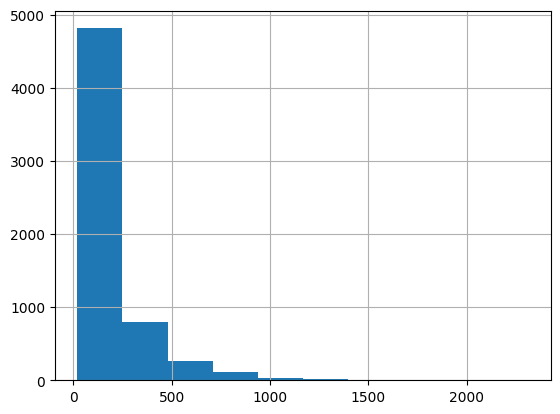

In [20]:
interactions_per_user = ratings.groupby("user_id").size()
print(interactions_per_user.describe())
print(interactions_per_user.hist())

### BUILD INTERACTION MATRIX WITH TRAIN DATA


In [53]:
def user_item_interaction_matrix(data,user_col_name,item_col_name,pref_col_name):
    num_users=len(data[user_col_name].unique())
    num_items=len(data[item_col_name].unique())
    pref_matrix=np.zeros((num_users,num_items))
    
    for idx in range(len(data)):
        print("HEre")
        curr_user,curr_item,curr_pref=data[user_col_name][idx],data[item_col_name][idx],data[pref_col_name][idx]
        print(curr_item,num_items)
        pref_matrix[curr_user][curr_item]=curr_pref
    
    return pref_matrix
        
mat=user_item_interaction_matrix(train,"user_id","movie_id","rating")


HEre
1193 3666
HEre
661 3666
HEre
914 3666
HEre
3408 3666
HEre
2355 3666
HEre
1197 3666
HEre
1287 3666
HEre
2804 3666
HEre
594 3666
HEre
919 3666
HEre
595 3666
HEre
938 3666
HEre
2398 3666
HEre
2918 3666
HEre
1035 3666
HEre
2791 3666
HEre
2687 3666
HEre
2018 3666
HEre
3105 3666
HEre
2797 3666
HEre
2321 3666
HEre
720 3666
HEre
1270 3666
HEre
527 3666
HEre
2340 3666
HEre


KeyError: 25

In [50]:
len(train["movie_id"].unique())

3666